# Validação visual — batching (β), granularidade territorial e visão geral do ataque

Notebook curto, complementar aos três anteriores. Cobre três lacunas
identificadas numa revisão do gerador antes do commit: (1) fragmentação β
não tinha nenhuma representação visual, apesar de ser a estratégia de
evasão central do adversário; (2) `granularidade`/`unidade_alvo` (mirar uma
única unidade territorial) também não; (3) nenhum notebook mostrava as três
camadas juntas, num único cenário adversarial, lado a lado com o modo
normal. Este notebook fecha os três pontos, sem repetir o que os notebooks
anteriores já cobrem (conformidade, competição eleitoral, tráfego de fundo
isolado).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kendalltau

from src.generator.layer1_abm import ElectionModel
from src.generator.layer2_copula import gerar_fonte_b
from src.generator.normal_mode import contagem_por_timestep, gerar_cenario_normal

plt.rcParams["figure.dpi"] = 100
print(f"Projeto em: {PROJECT_ROOT}")

C:\Users\Dell\Desktop\TCC_Projeto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projeto em: C:\Users\Dell\Desktop\TCC_Projeto


## 1. Batching (β): amplitude do pico de Fonte A antes e depois da fragmentação

`aplicar_batching` (Camada 2) é chamado por `resolver_desembolso()` sempre
que `beta > 1`: cada desembolso original é fragmentado em β sub-eventos
dentro de `[t, t + delta_t/β)`, cada um carregando `recompensa/β`. A
propriedade esperada (`docs/adversary_model_draft.tex`, Property 1): reduzir
a amplitude do pico observável por um fator ~1/β, para um total pago fixo —
a estratégia de evasão do adversário.

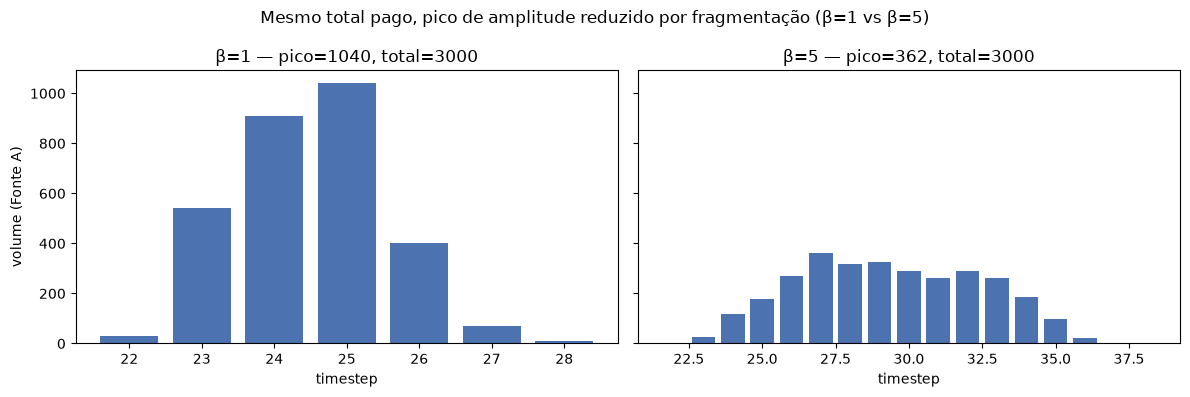

In [2]:
kwargs_batching = dict(
    n_agentes=300,
    prop_racional=1.0,
    recompensa=10.0,
    threshold_range=(0.0, 0.3),
    resultado_alvo=0.0,
    delta_t=50.0,
    rho=1.0,
    seed=7,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, beta in zip(axes, (1, 5)):
    modelo = ElectionModel(beta=beta, **kwargs_batching)
    modelo.run()
    modelo.resolver_desembolso()
    fonte_a = modelo.fonte_a_eventos_fronteira()

    ax.bar(fonte_a["timestep"], fonte_a["volume"], color="#4C72B0", width=0.8)
    ax.set_title(f"β={beta} — pico={fonte_a['volume'].max():.0f}, total={fonte_a['volume'].sum():.0f}")
    ax.set_xlabel("timestep")

axes[0].set_ylabel("volume (Fonte A)")
fig.suptitle("Mesmo total pago, pico de amplitude reduzido por fragmentação (β=1 vs β=5)")
fig.tight_layout()
plt.show()

**Leitura:** o pico cai de forma visível (β=1 → β=5), com o total
monetário pago idêntico nos dois painéis (a fragmentação muda só a
distribuição temporal, nunca o valor total — já garantido por
`test_beta_nao_muda_volume_monetario_agregado`). Isso é o que sustenta a
propriedade de evasão do adversário: o mesmo suborno fica mais difícil de
detectar por amplitude de pico.

**Achado honesto, não escondido: essa redução não é monotônica em β.**
`aplicar_batching` usa uma janela de fragmentação `delta_t/β` — que
**encolhe** conforme β cresce. Cada evento original ainda concentra seus β
fragmentos bem perto de si mesmo quando β é grande, então, a partir de um
certo ponto, aumentar β volta a *concentrar* os fragmentos (em vez de
espalhá-los), e o pico observável sobe de novo. A célula abaixo varre
β ∈ {1, 2, 3, 5, 8, 10, 15, 20} (os dois primeiros coincidem com os níveis
do PLANO, β ∈ {1, 5, 20}) para deixar isso visível, em vez de mostrar só o
par β=1/β=5 que esconderia o efeito.

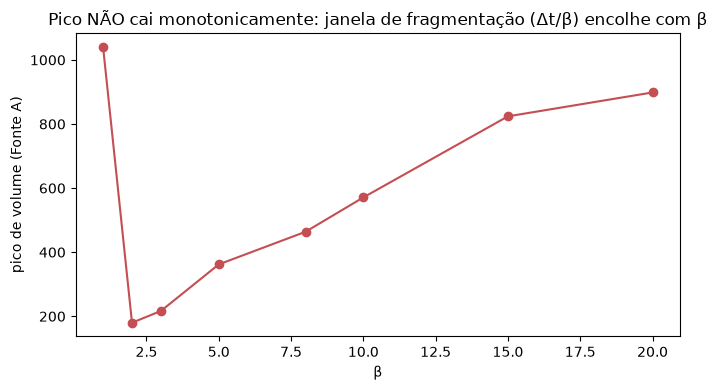

β=  1: janela_fragmento=50.00  pico_volume= 1040.0
β=  2: janela_fragmento=25.00  pico_volume=  180.0
β=  3: janela_fragmento=16.67  pico_volume=  216.7
β=  5: janela_fragmento=10.00  pico_volume=  362.0
β=  8: janela_fragmento= 6.25  pico_volume=  463.8
β= 10: janela_fragmento= 5.00  pico_volume=  571.0
β= 15: janela_fragmento= 3.33  pico_volume=  824.0
β= 20: janela_fragmento= 2.50  pico_volume=  898.5


In [3]:
valores_beta = [1, 2, 3, 5, 8, 10, 15, 20]
picos = []

for beta in valores_beta:
    modelo = ElectionModel(beta=beta, **kwargs_batching)
    modelo.run()
    modelo.resolver_desembolso()
    fonte_a = modelo.fonte_a_eventos_fronteira()
    picos.append(fonte_a["volume"].max())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(valores_beta, picos, "o-", color="#C44E52")
ax.set_xlabel("β")
ax.set_ylabel("pico de volume (Fonte A)")
ax.set_title("Pico NÃO cai monotonicamente: janela de fragmentação (Δt/β) encolhe com β")
fig.tight_layout()
plt.show()

for beta, pico in zip(valores_beta, picos):
    print(f"β={beta:3d}: janela_fragmento={kwargs_batching['delta_t']/beta:5.2f}  pico_volume={pico:7.1f}")

**Implicação para a reunião:** a propriedade "β reduz amplitude por
~1/β" (documentada no adversary model) vale para a faixa baixa de β nesta
configuração (β=1→2), mas se inverte para β mais alto, porque a janela de
fragmentação `Δt/β` e o bucketing por timestep inteiro de
`fonte_a_eventos_fronteira()` interagem: fragmentos de um mesmo evento
voltam a se concentrar quando a janela fica menor que alguns timesteps. Não
é um bug de implementação — `aplicar_batching` faz exatamente o que a
docstring descreve (`[0, Δt/β]`) — é uma consequência não óbvia da
combinação com o bucketing inteiro, que só apareceu ao visualizar. Fica
registrado aqui como ponto de discussão, não corrigido silenciosamente
(mesmo espírito do achado do Sanity Check 2 no notebook de conformidade).

## 2. Granularidade territorial: a mesma configuração, dois resultados de ativação

`resolver_desembolso()` pode checar o resultado do pool inteiro (default,
`granularidade="pool"`) ou de uma única seção/município/estado
(`unidade_alvo`). Usamos a mesma configuração exata em dois modelos,
variando só a granularidade, para mostrar que ela é de fato respeitada — o
resultado agregado do pool passa do alvo, mas a seção isolada escolhida
fica abaixo.

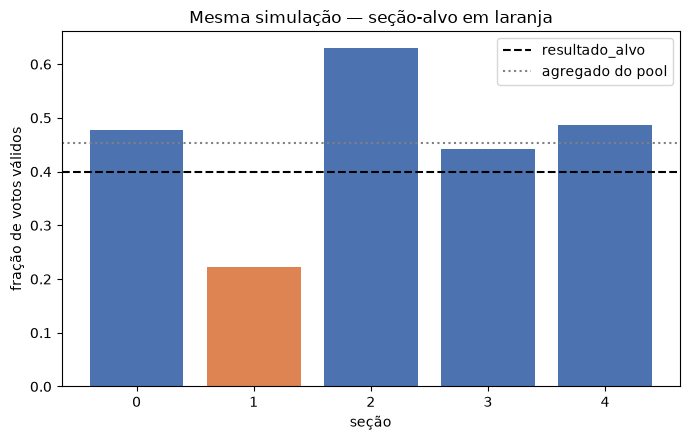

granularidade='pool'                    -> contrato_ativado=True  (agregado=0.453 >= alvo=0.4)
granularidade='secao', unidade_alvo=1  -> contrato_ativado=False  (seção 1=0.222 < alvo=0.4)

eventos_desembolso: pool=68  secao=0


In [4]:
kwargs_gran = dict(
    n_agentes=150,
    n_secoes=5,
    alpha_beta=(0.5, 0.5),
    prop_racional=1.0,
    recompensa=3.0,
    threshold_range=(0.0, 3.0),
    resultado_alvo=0.4,
    seed=1,
)
SECAO_ALVO = 1

modelo_pool = ElectionModel(granularidade="pool", **kwargs_gran)
modelo_pool.run()
modelo_pool.resolver_desembolso()

modelo_secao = ElectionModel(granularidade="secao", unidade_alvo=SECAO_ALVO, **kwargs_gran)
modelo_secao.run()
modelo_secao.resolver_desembolso()

resultado_por_secao = modelo_pool.resultado_eleitoral_por_secao()

fig, ax = plt.subplots(figsize=(7, 4.5))
cores = ["#DD8452" if i == SECAO_ALVO else "#4C72B0" for i in resultado_por_secao.index]
ax.bar(resultado_por_secao.index, resultado_por_secao.values, color=cores)
ax.axhline(kwargs_gran["resultado_alvo"], color="black", linestyle="--", label="resultado_alvo")
ax.axhline(modelo_pool.fonte_c_resultado_agregado(), color="gray", linestyle=":", label="agregado do pool")
ax.set_xlabel("seção")
ax.set_ylabel("fração de votos válidos")
ax.set_title("Mesma simulação — seção-alvo em laranja")
ax.legend()
fig.tight_layout()
plt.show()

print(f"granularidade='pool'                    -> contrato_ativado={modelo_pool.contrato_ativado}  "
      f"(agregado={modelo_pool.fonte_c_resultado_agregado():.3f} >= alvo={kwargs_gran['resultado_alvo']})")
print(f"granularidade='secao', unidade_alvo={SECAO_ALVO}  -> contrato_ativado={modelo_secao.contrato_ativado}  "
      f"(seção {SECAO_ALVO}={resultado_por_secao[SECAO_ALVO]:.3f} < alvo={kwargs_gran['resultado_alvo']})")
print(f"\neventos_desembolso: pool={len(modelo_pool.eventos_desembolso)}  secao={len(modelo_secao.eventos_desembolso)}")

**Leitura:** a barra laranja (seção 1, a unidade mirada) fica abaixo
da linha tracejada (`resultado_alvo`), mesmo com o agregado do pool inteiro
(linha pontilhada cinza) passando do alvo — por isso `granularidade="pool"`
ativa o contrato e `granularidade="secao", unidade_alvo=1` não. Note que
`eventos_desembolso` fica vazio no segundo caso: sem ativação, não há
desembolso — é a mesma lógica de "sem contrato, sem pagamento" dos outros
notebooks, agora causada pela granularidade, não pela ausência de adesão.

## 3. Visão geral: um cenário adversarial completo vs. um cenário normal completo

Os notebooks anteriores validam cada mecanismo isoladamente. Aqui, as três
fontes de um cenário adversarial completo (Fase 1 → Fase 2 → Fonte A →
Fonte B acoplada via cópula) ficam lado a lado com as três fontes do modo
normal (`gerar_cenario_normal`, sem CSC) — mesma janela de observação, para
comparação direta.

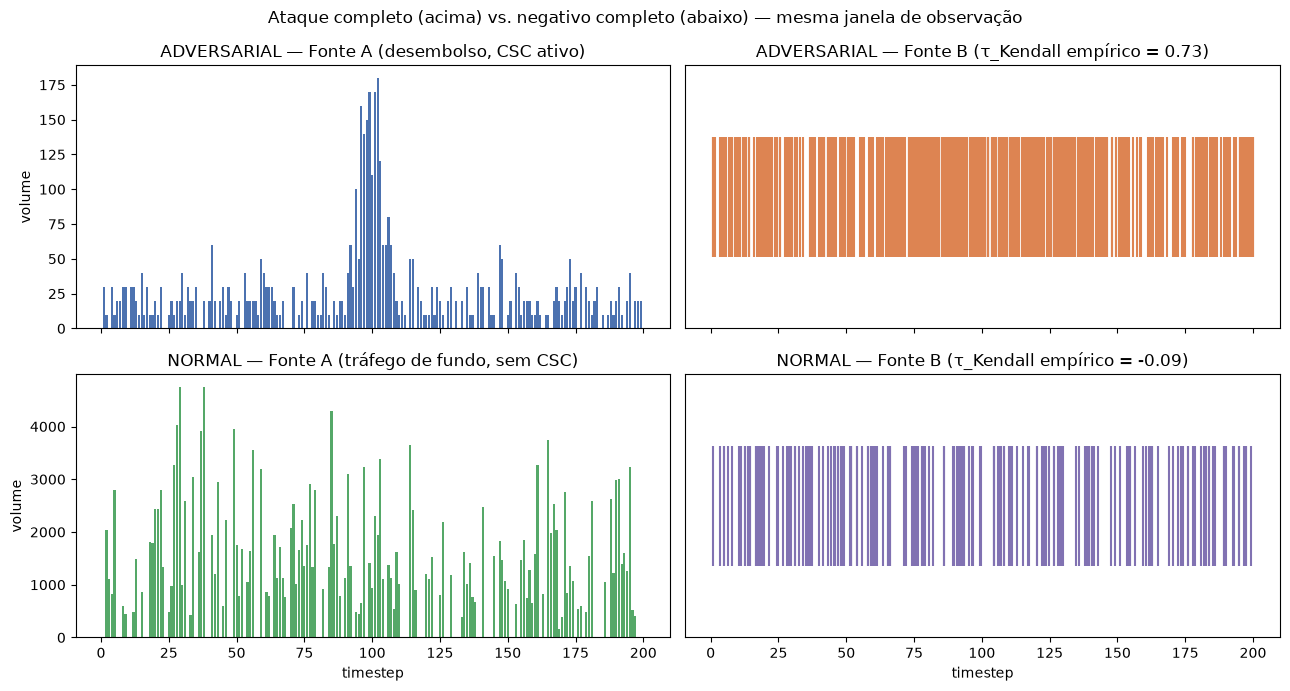

ADVERSARIAL: contrato_ativado=True  n(A)=498  n(B)=498  τ_Kendall(A,B)=0.732
NORMAL:      contrato_ativado=None  n(A)=234  n(B)=191  τ_Kendall(A,B)=-0.091

Fonte C adversarial (por seção):
0    0.866071
1    0.909091
2    0.850000
3    0.900990
4    0.897727
Name: fracao_candidato_alvo, dtype: float64

Fonte C normal (por seção):
0    0.276786
1    0.282828
2    0.280000
3    0.237624
4    0.250000
Name: fracao_candidato_alvo, dtype: float64


In [5]:
JANELA = 200.0

# Cenario adversarial: ElectionModel real + Camada 2 (copula) acoplando Fonte B a Fonte A
modelo_adv = ElectionModel(
    n_agentes=500, n_secoes=5, n_candidatos=1, prop_racional=1.0, recompensa=10.0,
    threshold_range=(0.0, 0.3), resultado_alvo=0.0, delta_t=JANELA, rho=0.3,
    prob_conformidade=0.9, seed=1,
)
modelo_adv.run()
modelo_adv.resolver_desembolso()
fonte_a_adv = modelo_adv.fonte_a_eventos_fronteira()
timestamps_a_adv = np.repeat(fonte_a_adv["timestep"].to_numpy(dtype=float), fonte_a_adv["n_eventos"].to_numpy())
fonte_b_adv = gerar_fonte_b(timestamps_a_adv, janela=JANELA, tau_kendall=0.8, random_state=2)
tau_adv, _ = kendalltau(timestamps_a_adv, fonte_b_adv)

# Cenario normal: mesma janela, Poisson independente + eleicao real sem CSC
modelo_normal = ElectionModel(n_agentes=500, n_secoes=5, n_candidatos=5, recompensa=0.0, seed=1)
cenario_normal = gerar_cenario_normal(
    modelo_normal, JANELA, taxa_fonte_a=1.0, volume_medio_fonte_a=1000.0, taxa_fonte_b=1.0,
    random_state_fonte_a=10, random_state_fonte_b=20,
)
timestamps_a_normal = np.repeat(
    cenario_normal.fonte_a["timestep"].to_numpy(dtype=float), cenario_normal.fonte_a["n_eventos"].to_numpy()
)
contagem_a_normal = contagem_por_timestep(timestamps_a_normal, JANELA)
contagem_b_normal = contagem_por_timestep(cenario_normal.fonte_b, JANELA)
tau_normal, _ = kendalltau(contagem_a_normal, contagem_b_normal)

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

axes[0, 0].bar(fonte_a_adv["timestep"], fonte_a_adv["volume"], color="#4C72B0", width=0.8)
axes[0, 0].set_title("ADVERSARIAL — Fonte A (desembolso, CSC ativo)")
axes[0, 0].set_ylabel("volume")

axes[0, 1].eventplot(fonte_b_adv, color="#DD8452", linewidths=1.5)
axes[0, 1].set_yticks([])
axes[0, 1].set_title(f"ADVERSARIAL — Fonte B (τ_Kendall empírico = {tau_adv:.2f})")

axes[1, 0].bar(cenario_normal.fonte_a["timestep"], cenario_normal.fonte_a["volume"], color="#55A868", width=0.8)
axes[1, 0].set_title("NORMAL — Fonte A (tráfego de fundo, sem CSC)")
axes[1, 0].set_ylabel("volume")
axes[1, 0].set_xlabel("timestep")

axes[1, 1].eventplot(cenario_normal.fonte_b, color="#8172B2", linewidths=1.5)
axes[1, 1].set_yticks([])
axes[1, 1].set_title(f"NORMAL — Fonte B (τ_Kendall empírico = {tau_normal:.2f})")
axes[1, 1].set_xlabel("timestep")

fig.suptitle("Ataque completo (acima) vs. negativo completo (abaixo) — mesma janela de observação")
fig.tight_layout()
plt.show()

print(f"ADVERSARIAL: contrato_ativado={modelo_adv.contrato_ativado}  n(A)={len(timestamps_a_adv)}  "
      f"n(B)={len(fonte_b_adv)}  τ_Kendall(A,B)={tau_adv:.3f}")
print(f"NORMAL:      contrato_ativado={modelo_normal.contrato_ativado}  n(A)={len(timestamps_a_normal)}  "
      f"n(B)={len(cenario_normal.fonte_b)}  τ_Kendall(A,B)={tau_normal:.3f}")
print(f"\nFonte C adversarial (por seção):\n{modelo_adv.resultado_eleitoral_por_secao()}")
print(f"\nFonte C normal (por seção):\n{cenario_normal.resultado_por_secao}")

**Leitura:** no cenário adversarial (linha de cima), Fonte A tem um
padrão de pico visível na janela pós-resultado e Fonte B fica visivelmente
correlacionada com ela (τ_Kendall empírico bem acima do limiar de 0.4 do
Sanity Check 2 — usando aqui ρ=0.3, não ρ=1.0, que é o caso conhecido onde
a correlação colapsa, já caracterizado no notebook de conformidade). No
cenário normal (linha de baixo), Fonte A e Fonte B são dois processos de
Poisson independentes — sem relação temporal visível entre si, τ_Kendall
próximo de zero — e mesmo assim Fonte C mostra uma eleição real acontecendo
(`contrato_ativado is None`: não existe CSC nesta amostra).

Esta é a comparação central que o gerador precisa sustentar para o pipeline
de detecção: as três fontes, no mesmo formato, uma vez com o sinal
adversarial presente e uma vez sem — a diferença observável entre as duas
linhas é o que um detector precisará aprender a distinguir.